In [ ]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import kagglehub
dataset_opt_path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")





In [ ]:
dataset_path = os.path.join(dataset_opt_path, "PetImages")
categories = ["Cat", "Dog"]
img_size = (64, 64)

X1 = []
y1 = []

for label, category in enumerate(categories):
    category_path = os.path.join(dataset_path, category)
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        try:
            # Чтение изображения в оттенках серого
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None or img.shape[0] == 0 or img.shape[1] == 0:
                continue
            # Изменение размера и нормализация
            img = cv2.resize(img, img_size)
            img = img / 255.0  # Нормализация в диапазон [0, 1]
            X1.append(img.flatten())
            y1.append(label)
        except Exception as e:
            print(f"Error processing {img_path}: {str(e)}")
            continue

In [ ]:
X = np.array(X1)
y = np.array(y1)

X = np.array(X)[11500:13500]
y = np.array(y)[11500:13500]

print(f"Total samples loaded: {len(X)}")
print(f"Shape of X: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Total samples loaded: 2000
Shape of X: (2000, 4096)


In [ ]:
# SVM без PCA
clf = SVC(kernel='linear', probability=True)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)
base_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy without PCA: {base_accuracy:.4f}")
print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred, target_names=categories))

Accuracy without PCA: 0.5000

Classification Report (Baseline):
              precision    recall  f1-score   support

         Cat       0.49      0.47      0.48       195
         Dog       0.51      0.53      0.52       205

    accuracy                           0.50       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.50      0.50      0.50       400



In [ ]:
# определение количества компонент
print("\nPerforming PCA...")
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)


Performing PCA...


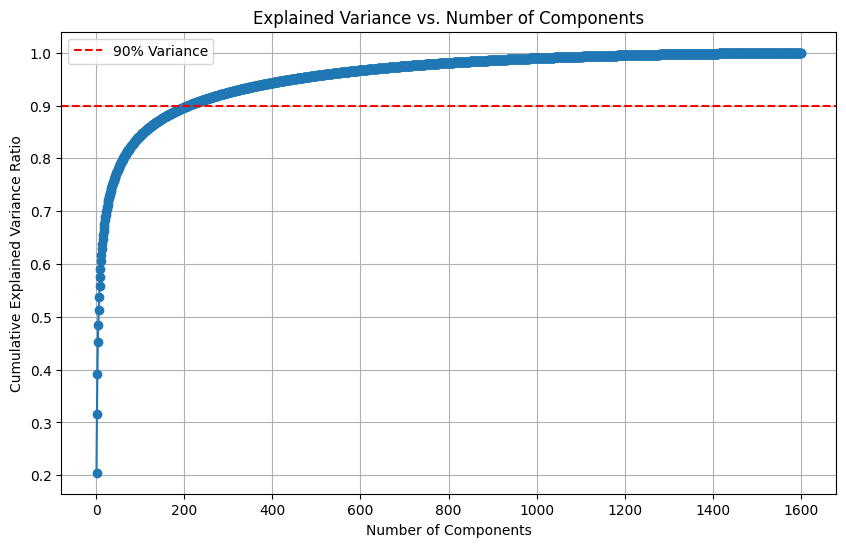

In [ ]:
# Построение графика объясненной дисперсии
explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.title("Explained Variance vs. Number of Components")
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance')
plt.legend()
plt.show()

In [ ]:
# Выбор компонент, объясняющих 90% дисперсии
n_components_90 = np.argmax(explained_variance_ratio >= 0.9) + 1
print(f"\nNumber of components explaining 90% variance: {n_components_90}")


Number of components explaining 90% variance: 210


In [ ]:
# Применение PCA с выбранным числом компонент
pca = PCA(n_components=n_components_90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
# SVM с PCA
clf_pca = SVC(kernel='linear', probability=True)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)
pca_accuracy = accuracy_score(y_test, y_pred_pca)
print("\nClassification Report (PCA):")
print(classification_report(y_test, y_pred_pca, target_names=categories))


Classification Report (PCA):
              precision    recall  f1-score   support

         Cat       0.51      0.50      0.51       195
         Dog       0.54      0.55      0.54       205

    accuracy                           0.53       400
   macro avg       0.52      0.52      0.52       400
weighted avg       0.52      0.53      0.52       400



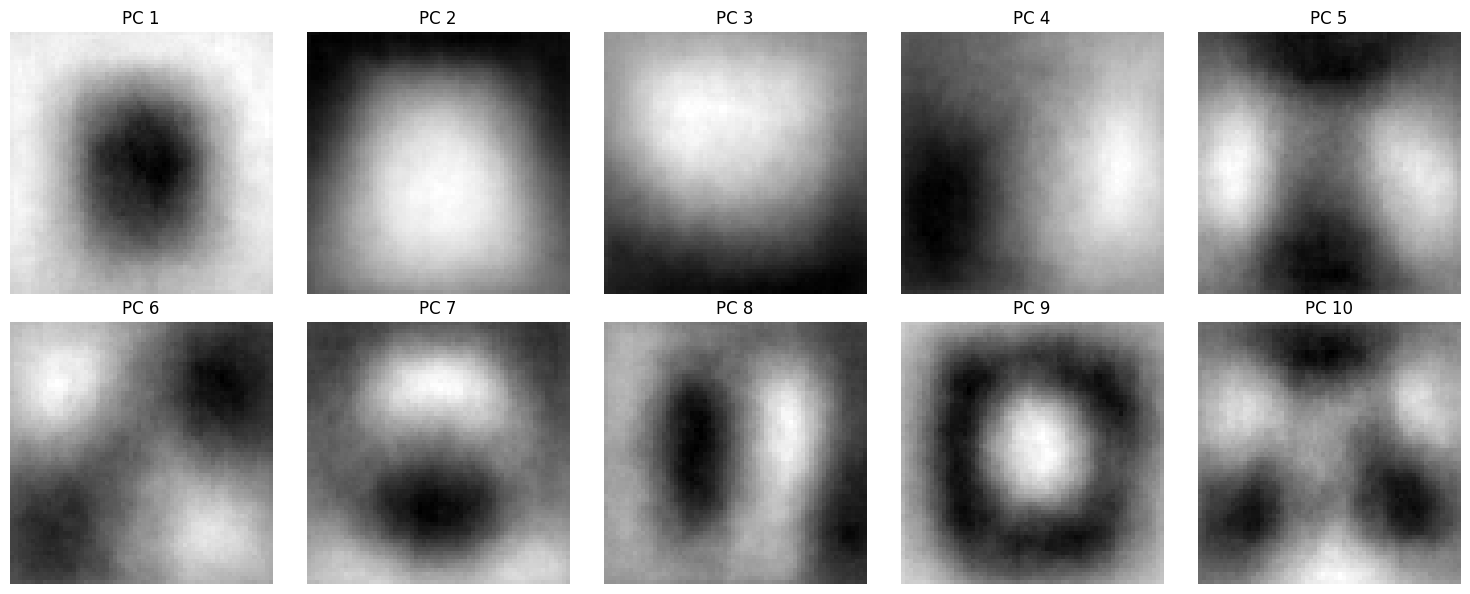

In [ ]:
# отображение первых 10 главных компонент
components = pca.components_[:10]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    component_img = components[i].reshape(img_size)
    # нормализация для визуализации
    component_img = (component_img - component_img.min()) / (component_img.max() - component_img.min())
    ax.imshow(component_img, cmap='gray')
    ax.set_title(f"PC {i+1}")
    ax.axis("off")
plt.tight_layout()
plt.show()


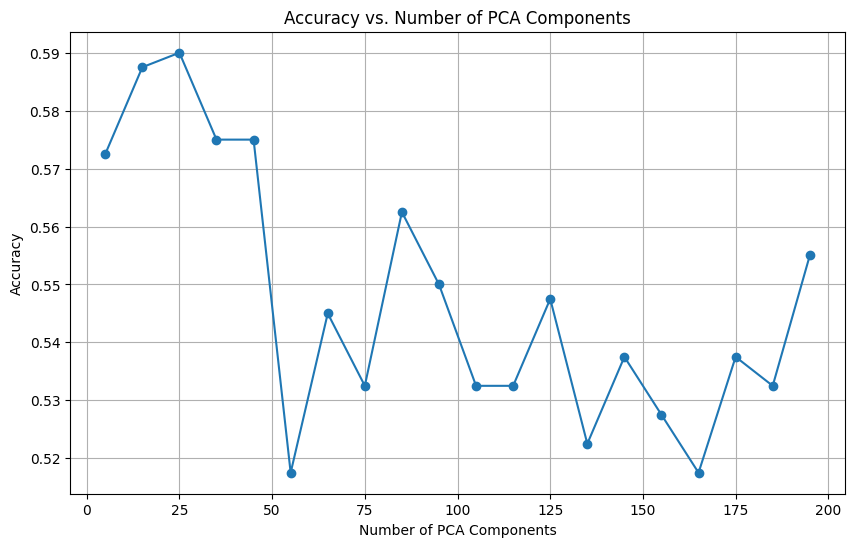

In [ ]:
accuracies = []
component_range = range(5, 201, 10)

for n in component_range:
    pca = PCA(n_components=n)
    X_train_pca_n = pca.fit_transform(X_train_scaled)
    X_test_pca_n = pca.transform(X_test_scaled)

    clf_n = SVC(kernel='linear')
    clf_n.fit(X_train_pca_n, y_train)
    y_pred_n = clf_n.predict(X_test_pca_n)
    acc = accuracy_score(y_test, y_pred_n)
    accuracies.append(acc)

# График
plt.figure(figsize=(10, 6))
plt.plot(component_range, accuracies, marker='o')
plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Number of PCA Components")
plt.grid(True)
plt.show()